In [1]:
# env: behav_fit2 - works
# plot raw behavior in plot_rawData.ipynb

from stress_risk.behavior.utils import get_data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
import bambi
bids_folder = '/Users/mrenke/data/ds-stressrisk'

target_folder = op.join(bids_folder, 'derivatives', 'cogmodels')
df = get_data()
df['x'] = df['log(risky/safe)']

# 1. fit model and save traces
# 2. load traces and extract rnp, (& gamma & intercept)
# 3. plot RNP  x= ses1/ses2, hue=group0/group1 
# 4. plot posterior chains (gamma, intercept, RNP)
# 4.1 ses2-ses1 / group1-group2
# 4.2 diff of diff
# ...
# check correlations, model comparison, 
# look at posterior_predictive_probit


/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 1. fit probit modelling

n_model = 5

if n_model == 1:
    formulae = 'chose_risky ~ x*session*group + (x*session|subject)' # 1
elif n_model == 2:
    formulae = 'chose_risky ~ x*session:group + (x*session|subject)' # no main effect of group # 2
elif n_model == 3:
    formulae = 'chose_risky ~ x*session + session:group + x*session:group + (x*session|subject)' # 3
elif n_model == 4:
    formulae = 'chose_risky ~ x*risky_first*n_safe*session:group + (x*risky_first*n_safe*session|subject)' # 3
elif n_model == 5:
    formulae = 'chose_risky ~ x*risky_first*C(n_safe)*C(session)*C(group) + (x*risky_first*C(n_safe)*C(session)|subject)' # 3


model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())

# fit
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)

# save model fit
import arviz as az
az.to_netcdf(traces, op.join(target_folder, f'bambi-RNP-fit_trace_model{n_model}.netcdf'))

In [2]:
# 2. get parameters from trace
from utils import extract_rnp_precision
import arviz as az

n_model = 1
if n_model == 1:
    formulae = 'chose_risky ~ x*session*group + (x*session|subject)' # 1
elif n_model == 2:
    formulae = 'chose_risky ~ x*session:group + (x*session|subject)' # no main effect of group # 2
elif n_model == 3:
    formulae = 'chose_risky ~ x*session + x*session:group + (x*session|subject)' # 3
elif n_model == 4:
    formulae = 'chose_risky ~ x*risky_first*n_safe*session:group + (x*risky_first*n_safe*session|subject)' # 3
elif n_model == 5:
    formulae = 'chose_risky ~ x*risky_first*C(n_safe)*C(session)*C(group) + (x*risky_first*C(n_safe)*C(session)|subject)' # 3
elif n_model == 6:
    formulae = 'chose_risky ~ x + x*session + session + x:session:group + session:group + (x*risky_first*C(n_safe)*C(session)|subject)' # 3


model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())

traces= az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model{n_model}.netcdf'))
intercept, gamma = extract_rnp_precision(traces, model, df, True) # important 
rnp = np.clip(np.exp(intercept/gamma), 0, 1)


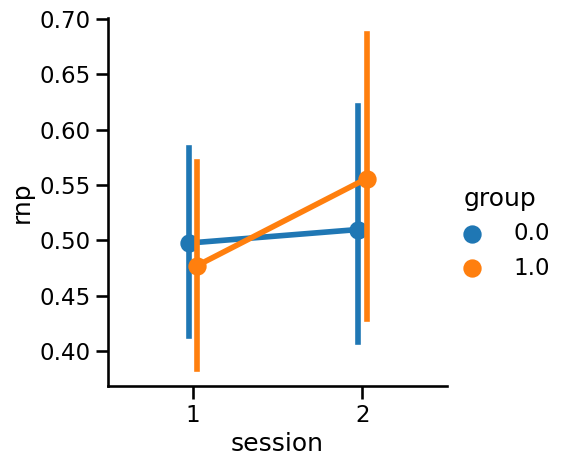

In [3]:
from arviz import hdi
sns.set_context('talk')

get_error_bar = lambda d: hdi(d.values)
tmp = rnp.stack([-1, -2])
tmp.columns = ['rnp']
tmp = tmp.reset_index()
sns.catplot(tmp, y='rnp', x='session', hue='group', kind='point',
            errorbar=get_error_bar, dodge=True) # x='n_safe', y='rnp', hue='session', col='group', row='risky_first'

In [16]:
tmp

rnp     gamma  intercept  group
subject session                                      
1       1        0.600260  2.892456  -1.481595      0
        2        0.600111  3.229501  -1.669011      0
2       1        0.545680  2.609244  -1.590322      0
        2        0.684008  3.074884  -1.214223      0
3       1        0.521614  1.813866  -1.181555      1
...                   ...       ...        ...    ...
58      2        0.483389  2.132658  -1.579862      1
59      1        0.387507  2.525307  -2.395071      0
        2        0.464295  3.088420  -2.400178      0
61      1        0.583817  2.571492  -1.393990      0
        2        0.611670  2.748749  -1.388498      0

[100 rows x 4 columns]

In [29]:
# 4. plot posterior estimates
import os

model_name = f'bambi-RNP-fit_model{n_model}'
if not op.exists(op.join(target_folder, 'figures',model_name)):
    os.makedirs(op.join(target_folder, 'figures',model_name))

g = gamma.stack([1,2])
g.columns  = ['gamma']
g = g.reset_index()

i = intercept.stack([1,2])
i.columns  = ['intercept']
i = i.reset_index()

r = rnp.stack([1,2])
r.columns  = ['y']
r = r.reset_index()



In [46]:
# single differences
sns.set_context('talk')

# gamma
d = g
for group in [0,1]:
    dd= np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('gamma')
    plt.title(f'group{group}, ses2 - ses1, p={np.mean(dd>0)}')
    np.mean(dd>0)
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'gamma_group{group}_ses1-ses2'))
    plt.close()

for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['gamma']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['gamma'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('gamma')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'gamma_session{ses}_group1-group0'))
    plt.close()

# intercept
d = i
for group in [0,1]:
    dd= np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('intercept')
    plt.title(f'group{group}, ses2 - ses1, p={np.mean(dd>0)}')
    np.mean(dd>0)
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'intercept_group{group}_ses1-ses2'))
    plt.close()


for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['intercept']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['intercept'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('intercept')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'intercept_session{ses}_group1-group0'))
    plt.close()

# rnp
d = r
for group in [0,1]:
    dd= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('rnp')
    plt.title(f'group{group}, ses2 - ses1,p={np.mean(dd>0)}')
    np.mean(dd>0)
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'rnp_group{group}_ses1-ses2'))
    plt.close()


for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['y']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['y'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('rnp')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(target_folder, 'figures',model_name, f'rnp_session{ses}_group1-group0'))
    plt.close()


In [47]:
# diff in diff
sns.set_context('talk')
# gamma
d = g
group = 0
dd_0= np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma'])
group = 1
dd_1= np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('gamma - diff in diff\n [(group1(ses2-ses1) - group0(ses2-ses1)]')
plt.title(f'p(gamma > 0)  = {str(np.mean(dd > 0))}')
plt.tight_layout()
sns.despine()
plt.savefig(op.join(target_folder, 'figures',model_name, f'diffOFdiff_gamma'))
plt.close()

# intercept
d = i
group = 0
dd_0= np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept'])
group = 1
dd_1= np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('intercept- diff in diff\n[(group1(ses2-ses1) - group0(ses2-ses1)]')
plt.title(f'p(intercept > 0)  = {str(np.mean(dd > 0))}')
plt.tight_layout()
sns.despine()
plt.savefig(op.join(target_folder, 'figures',model_name, f'diffOFdiff_intercept'))
plt.close()

# rnp
#rnp = np.clip(np.exp(intercept/gamma), 0, 1)
d = r
group = 0
dd_0= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
group = 1
dd_1= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('rnp- diff in diff\n [(group1(ses2-ses1) - group0(ses2-ses1)]')
plt.title(f'p(rnp > 0)  = {str(np.mean(dd > 0))}')
sns.despine()
plt.tight_layout()
plt.savefig(op.join(target_folder, 'figures', model_name, f'diffOFdiff_rnp'))
plt.close()


In [14]:
# save parameters
intercept, gamma = extract_rnp_precision(traces, model, df, False) # 
rnp = np.clip(np.exp(intercept/gamma), 0, 1)

n_model = 'tryout'
gamma_ = gamma.stack([1, 2]).groupby(['subject', 'session']).mean()
gamma_.columns = ['gamma']

intercept_ = intercept.stack([1, 2]).groupby(['subject', 'session']).mean()
intercept_.columns = ['intercept']

rnp_ = rnp.stack([1, 2]).groupby(['subject', 'session']).mean()
rnp_.columns = ['rnp']

params = rnp_.join(gamma_).join(intercept_)
params.to_csv(op.join(target_folder, 'param_estimates', f'bambi-{n_model}_subseswise_params.csv'))



/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [ ]:
# correlation of rnp and gamma
sns.lmplot(x='rnp', y='gamma', data=params)

In [ ]:
# model comparison

import arviz as az
data1 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model1.netcdf'))
data2 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model2.netcdf'))
data3 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model3.netcdf'))

compare_dict = {"model 1": data1, "model 2": data2,"model 3": data3}
az.compare(compare_dict)

In [15]:
# check parameter file
df_probit_params = pd.read_csv(f'/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates/bambi-{n_model}_subseswise_params.csv')
df_cond = pd.read_excel('/Users/mrenke/data/ds-stressrisk/addMeasures/data_combined.xlsx')

In [16]:
groups = df_cond.rename(columns={'SUBID':'subject', 'condition':'group'}).set_index('subject')[['group']]
tmp = df_probit_params.set_index(['subject', 'session']).join(groups)

tmp

rnp     gamma  intercept  group
subject session                                      
1       1        0.600260  2.892456  -1.481595      0
        2        0.600111  3.229501  -1.669011      0
2       1        0.545680  2.609244  -1.590322      0
        2        0.684008  3.074884  -1.214223      0
3       1        0.521614  1.813866  -1.181555      1
...                   ...       ...        ...    ...
58      2        0.483389  2.132658  -1.579862      1
59      1        0.387507  2.525307  -2.395071      0
        2        0.464295  3.088420  -2.400178      0
61      1        0.583817  2.571492  -1.393990      0
        2        0.611670  2.748749  -1.388498      0

[100 rows x 4 columns]

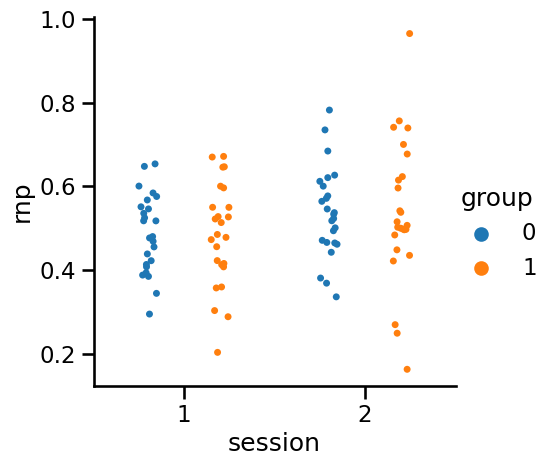

In [20]:
# shouldnt do group statistics on subject wise parameters from a hierahical model !!!

sns.catplot(tmp.reset_index(), x='session', y='rnp', hue='group', dodge=True)

In [5]:
tmp

,subject,session,group,risky_first,n_safe,draw,chain,rnp
0,1,1,0.0,True,10.0,0,0,0.501135
1,1,1,0.0,True,10.0,0,1,0.523546
2,1,1,0.0,True,10.0,0,2,0.473311
3,1,1,0.0,True,10.0,0,3,0.515679
4,1,1,0.0,True,10.0,1,0,0.524781
...,...,...,...,...,...,...,...,...
159995,1,2,1.0,False,20.0,998,3,0.504148
159996,1,2,1.0,False,20.0,999,0,0.666072
159997,1,2,1.0,False,20.0,999,1,0.613724
159998,1,2,1.0,False,20.0,999,2,0.561988
